In [3]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()   

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

response = client.embeddings.create(
    input=["Your text string goes here","qasdsd"],
    model="text-embedding-3-small"
)

print(response.data[0].embedding)

[0.005119773093611002, 0.01721755601465702, -0.018673349171876907, -0.018575362861156464, -0.0472852885723114, -0.03026370331645012, 0.027660073712468147, 0.003656980814412236, 0.011233405210077763, 0.0064180889166891575, -0.001710382173769176, 0.015831751748919487, -0.001323687145486474, -0.007852884940803051, 0.05985550209879875, 0.05028086155653, -0.02752009406685829, 0.009959585964679718, -0.040426261723041534, 0.05002889782190323, -0.0004026615933980793, 0.03026370331645012, -0.013704054988920689, 0.03289533033967018, 0.017329540103673935, 0.016769619658589363, -0.0017733732238411903, 0.020423101261258125, 0.04079021140933037, -0.03773864358663559, -0.0261622853577137, -0.049972906708717346, 0.02417456917464733, -0.05520816147327423, -0.032251421362161636, 0.04232998937368393, 0.0647268146276474, 0.014683915302157402, -0.01564977876842022, -0.04137812554836273, 0.022214846685528755, 0.0074189468286931515, 0.04496161639690399, 0.007089993450790644, -0.024076582863926888, 0.05240856

In [1]:
from beir.retrieval.evaluation import EvaluateRetrieval


In [24]:
import json
data = json.load(open("../results/bm25.json","r"))

In [26]:
from beir.datasets.data_loader import GenericDataLoader
import os
def load_dataset(dataset_path: str):
    corpus_path = os.path.join(dataset_path, "corpus.jsonl")
    query_path = os.path.join(dataset_path, "queries_with_questions.jsonl")
    qrels_path = os.path.join(dataset_path,'qrels', "test.tsv")
    print(f"Loading dataset from {corpus_path}, {query_path}, {qrels_path}")
    corpus, queries, qrels = GenericDataLoader(
        corpus_file=corpus_path, 
        query_file=query_path, 
        qrels_file=qrels_path).load_custom()

    return corpus, queries, qrels

corpus, queries, qrels = load_dataset("../jua-dataset")


Loading dataset from ../jua-dataset/corpus.jsonl, ../jua-dataset/queries_with_questions.jsonl, ../jua-dataset/qrels/test.tsv


100%|██████████| 17147/17147 [00:00<00:00, 65928.54it/s]


In [27]:
ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, data, [1,10,100,1000],ignore_identical_ids=False)

In [28]:
ndcg

{'NDCG@1': 0.44399,
 'NDCG@10': 0.60977,
 'NDCG@100': 0.64032,
 'NDCG@1000': 0.64613}

In [29]:

for q, docs in data.items():
    if q in list(docs.keys()):
        print(q)

JURISPRUDENCIA-SELECIONADA-21091
JURISPRUDENCIA-SELECIONADA-51915
JURISPRUDENCIA-SELECIONADA-30881
JURISPRUDENCIA-SELECIONADA-39691
JURISPRUDENCIA-SELECIONADA-31138
JURISPRUDENCIA-SELECIONADA-34143
JURISPRUDENCIA-SELECIONADA-34109
JURISPRUDENCIA-SELECIONADA-32973
JURISPRUDENCIA-SELECIONADA-35445
JURISPRUDENCIA-SELECIONADA-31588
JURISPRUDENCIA-SELECIONADA-31517
JURISPRUDENCIA-SELECIONADA-33902
JURISPRUDENCIA-SELECIONADA-31476
JURISPRUDENCIA-SELECIONADA-23583
JURISPRUDENCIA-SELECIONADA-18954
JURISPRUDENCIA-SELECIONADA-20606
JURISPRUDENCIA-SELECIONADA-31474
JURISPRUDENCIA-SELECIONADA-21124
JURISPRUDENCIA-SELECIONADA-34161
JURISPRUDENCIA-SELECIONADA-35457
JURISPRUDENCIA-SELECIONADA-31483
JURISPRUDENCIA-SELECIONADA-27087
JURISPRUDENCIA-SELECIONADA-31938
JURISPRUDENCIA-SELECIONADA-31305
JURISPRUDENCIA-SELECIONADA-31018
JURISPRUDENCIA-SELECIONADA-39618
JURISPRUDENCIA-SELECIONADA-35217
JURISPRUDENCIA-SELECIONADA-18823
JURISPRUDENCIA-SELECIONADA-31632
JURISPRUDENCIA-SELECIONADA-26270
JURISPRUDE

In [1]:
import pickle

with open("../embeddings/sbert_multi-qa-mpnet-base-dot-v1/corpus.0.pkl","rb") as f:
    corpus_embeddings = pickle.load(f)
with open("../embeddings/sbert_multi-qa-mpnet-base-dot-v1/queries.pkl","rb") as f:
    query_embeddings = pickle.load(f)

In [17]:
doc_embedding = corpus_embeddings[0][corpus_embeddings[1].index("JURISPRUDENCIA-SELECIONADA-28447")]

In [18]:
q_embedding = query_embeddings[0][0]

In [19]:
# prompt: compute cosine similarity
from numpy import dot
from numpy.linalg import norm
cosine_similarity = dot(doc_embedding, q_embedding) / (norm(doc_embedding) * norm(q_embedding))
cosine_similarity

np.float32(0.756669)

In [4]:
import json
from beir.retrieval.evaluation import EvaluateRetrieval

file = "../results/sbert_paraphrase-MiniLM-L3-v2.json"
data = json.load(open(file,"r"))
ndcg, _map, recall, precision = EvaluateRetrieval.evaluate(qrels, data, [1,10,100,1000],ignore_identical_ids=False)
ndcg

NameError: name 'qrels' is not defined

In [1]:
from google import genai

client = genai.Client()

result = client.models.embed_content(
        model="gemini-embedding-001",
        contents= [
            "What is the meaning of life?",
            "What is the purpose of existence?",
            "How do I bake a cake?"
        ]
)

for embedding in result.embeddings:
    print(embedding)
    

ImportError: cannot import name 'genai' from 'google' (unknown location)

In [52]:
import json
results_anserini = json.load(open("../results/anserini_bm25_partial.json", "r"))


In [23]:
positions = []
not_found = []
for query_id in results_anserini:
    
    if query_id[:-2] in results_anserini[query_id]:
        position = list(results_anserini[query_id].keys()).index(query_id[:-2]) + 1
        
        positions.append(position)  
        # print(results_anserini[query_id][query_id[:-2]])
    else:
        # print(f"Query ID: {query_id[:-2]} NOT FOUND")
        not_found.append(query_id[:-2])
    # print(query_id[:-2] in results_anserini[query_id])

In [24]:
len(not_found)

143

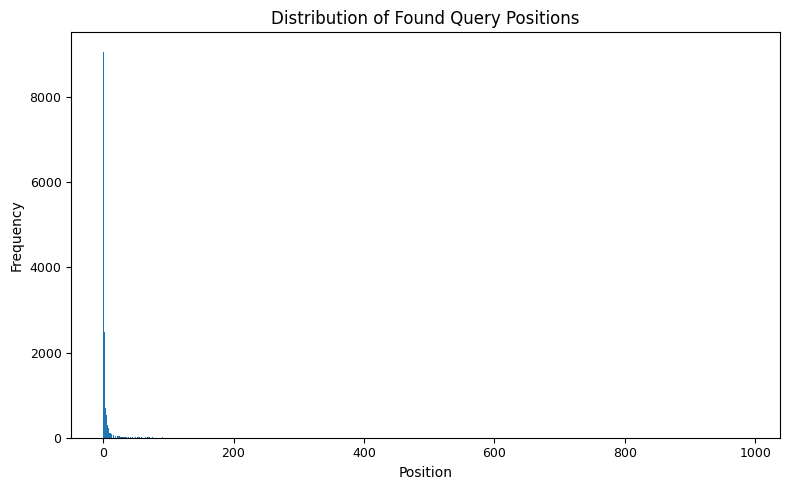

In [26]:
from collections import Counter
position_counts = Counter(positions)

# PLOT THE DISTRIBUTION
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(position_counts.keys(), position_counts.values())
plt.xlabel("Position", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.title("Distribution of Found Query Positions", fontsize=12)
plt.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

In [27]:
position_counts.most_common(10)

[(1, 9065),
 (2, 2472),
 (3, 1219),
 (4, 707),
 (5, 545),
 (6, 330),
 (7, 287),
 (8, 226),
 (9, 153),
 (10, 120)]

In [8]:
import pandas as pd

df = pd.read_csv("../data/jurisprudencia-selecionada-bm25.csv")
df.head()


,KEY,NUMACORDAO,ANOACORDAO,COLEGIADO,AREA,TEMA,SUBTEMA,ENUNCIADO,EXCERTO,NUMSUMULA,...,TIPOPROCESSO,TIPORECURSO,INDEXACAO,INDEXADORESCONSOLIDADOS,PARAGRAFOLC,REFERENCIALEGAL,PUBLICACAOAPRESENTACAO,PARADIGMATICO,title,BM25_RANK
0,JURISPRUDENCIA-SELECIONADA-189673,2002.0,2025.0,Plenário,Pessoal,Ato sujeito a registro,Princípio da ampla defesa,Não se exige a observância do contraditório e ...,"Fundamento legal:Constituição Federal, art. 71...",NaN,...,ADMINISTRATIVO,NaN,"[Registro tácito, Má-fé, Súmula, Princípio do ...",AREA: Pessoal ; TEMA: Ato sujeito a registro ;...,NaN,NaN,"[<a href=""http://contas.tcu.gov.br/egestao/Obt...",SUMULA,2002.0/2025.0,0
1,JURISPRUDENCIA-SELECIONADA-178617,122.0,2025.0,Plenário,Pessoal,Remuneração,Decisão judicial,As vantagens remuneratórias concedidas por dec...,"Fundamento legal:- Constituição Federal, art. ...",NaN,...,ADMINISTRATIVO,NaN,"[Absorção, Súmula, Vantagem pecuniária, Plano ...",AREA: Pessoal ; TEMA: Remuneração ; SUBTEMA: D...,NaN,[Súmula 291/2025 TCU],"[<a href=""http://contas.tcu.gov.br/egestao/Obt...",SUMULA,122.0/2025.0,1
2,JURISPRUDENCIA-SELECIONADA-175880,2345.0,2024.0,Plenário,Pessoal,Aposentadoria,Vantagem opção,É vedado o pagamento das vantagens oriundas do...,Fundamento legal:- Emenda Constitucional 20/19...,NaN,...,ADMINISTRATIVO,NaN,"[Súmula, Marco temporal, Vedação]",AREA: Pessoal ; TEMA: Aposentadoria ; SUBTEMA:...,NaN,[Lei Ordinária 8.112/1990 Art. 193 Congresso N...,"[<a href=""http://contas.tcu.gov.br/egestao/Obt...",SUMULA,2345.0/2024.0,2
3,JURISPRUDENCIA-SELECIONADA-172701,1686.0,2024.0,Plenário,Pessoal,Concessão (Pessoal),Cancelamento,SÚMULA TCU 199 (REVOGADA): Salvo por sua deter...,Voto:Aprecio processo autuado em cumprimento à...,NaN,...,ADMINISTRATIVO,NaN,"[Autoridade, Súmula]",AREA: Pessoal ; TEMA: Concessão (Pessoal) ; SU...,NaN,NaN,NaN,SUMULA,1686.0/2024.0,3
4,JURISPRUDENCIA-SELECIONADA-85414,358.0,2020.0,Plenário,Finanças Públicas,Regime Próprio de Previdência Social,Pensão,SÚMULA TCU 42 (REVOGADA): As Pensões deixadas ...,Relatório:Trata-se de estudo elaborado pela Se...,NaN,...,ADMINISTRATIVO,NaN,"[Guanabara, Súmula, Pensão militar, Polícia Mi...",AREA: Finanças Públicas ; TEMA: Regime Próprio...,NaN,NaN,NaN,SUMULA,358.0/2020.0,4


In [31]:
qrdy = "JURISPRUDENCIA-SELECIONADA-31476"
df[df["KEY"] == qrdy]

,KEY,NUMACORDAO,ANOACORDAO,COLEGIADO,AREA,TEMA,SUBTEMA,ENUNCIADO,EXCERTO,NUMSUMULA,...,TIPOPROCESSO,TIPORECURSO,INDEXACAO,INDEXADORESCONSOLIDADOS,PARAGRAFOLC,REFERENCIALEGAL,PUBLICACAOAPRESENTACAO,PARADIGMATICO,title,BM25_RANK
17055,JURISPRUDENCIA-SELECIONADA-31476,2606.0,2008.0,Plenário,Gestão Administrativa,Sistema S,Princípio,Os serviços sociais autônomos devem realizar a...,Sumário:1. As entidades do Sistema s devem rea...,NaN,...,PRESTAÇÃO DE CONTAS SIMPLIFICADA,NaN,"[Seleção de pessoal, Legislação, Licitação, Co...",AREA: Gestão Administrativa ; TEMA: Sistema S ...,NaN,[Constituição Federal 1988 Art. 37 Congresso N...,NaN,NaN,2606.0/2008.0,17138


In [27]:
new_df = df.sort_values(by="BM25_RANK", ascending=True).head(int(len(df) * 0.1))

In [29]:
max(new_df["BM25_RANK"])

1712

In [19]:
# random sample 10% from df
new_df = df.sample(frac=0.1, random_state=42)

In [22]:
import os
test_qrels_df = pd.DataFrame({
    "query-id": new_df["KEY"]+ "-q",
    "corpus-id": new_df["KEY"],
    "score": 1
})
# save test qrels to json file
test_qrels_df.to_csv(os.path.join("../jua-dataset",'qrels', "test_random.tsv"), index=False, sep="\t")

In [34]:
import random
import math
from collections import defaultdict

# =========================
# 1) Calcular rank + métricas
# =========================

def compute_query_stats(results):
    stats = {}

    for qid, ranking in results.items():
        sorted_docs = sorted(ranking.items(), key=lambda x: x[1], reverse=True)

        target = qid[:-2]  # sua regra

        rank = math.inf
        target_score = None
        top_score = None

        if sorted_docs:
            top_score = sorted_docs[0][1]

        for i, (doc_id, score) in enumerate(sorted_docs, start=1):
            if doc_id == target:
                rank = i
                target_score = score
                break

        gap_top = (top_score - target_score) if target_score is not None else None

        stats[qid] = {
            "rank": rank,
            "gap_top": gap_top,
            "target_found": target_score is not None
        }

    return stats


# =========================
# 2) Dificuldade contínua
# =========================

def compute_difficulty_scores(
    stats,
    max_k=1000,
    w_rank=0.65,
    w_gap=0.35,
    not_found_boost=1.25,
    cap_rank_at_k=True
):
    """
    Retorna dict[qid] -> difficulty (float, maior = mais difícil)

    - w_rank, w_gap: pesos.
    - not_found_boost: multiplicador controlado pros not_found
    - cap_rank_at_k: se rank>max_k (ou inf), trata como max_k+1
    """

    diffs = {}
    for qid, s in stats.items():
        rank = s["rank"]
        gap = s["gap_top"]

        if rank == math.inf:
            # "rank virtual" pra not-found
            r = max_k + 1
            rank_term = math.log(r)
            gap_term = math.log1p(max_k)  # valor "alto" fixo (controlado)
            base = w_rank * rank_term + w_gap * gap_term
            diffs[qid] = base * not_found_boost
            continue

        # opcional: capar rank acima de K (se você usa top-K truncado)
        r = min(rank, max_k) if cap_rank_at_k else rank

        rank_term = math.log(r)  # log(1)=0, log cresce devagar
        gap_term = math.log1p(gap) if gap is not None and gap >= 0 else 0.0

        diffs[qid] = w_rank * rank_term + w_gap * gap_term

    return diffs


# =========================
# 3) Bins log (mantém seu método)
# =========================

def get_log_bin(rank, max_k=1000):
    if rank == math.inf:
        return "not_found"
    if rank <= 1:
        return "bin_1"
    b = 2 ** math.ceil(math.log2(rank))
    return f"bin_{b}"

def build_bins(stats, max_k=1000):
    bins = defaultdict(list)
    for qid, s in stats.items():
        b = get_log_bin(s["rank"], max_k)
        bins[b].append(qid)
    return bins


# =========================
# 4) Seleção "research-grade"
# =========================

def select_queries_research_grade(
    results,
    max_k=1000,
    # quotas
    total_n=2000,
    pct_not_found=0.25,   # 25% not-found
    pct_hard=0.45,        # 45% hard/very-hard (bins altos)
    pct_medium=0.25,      # 25% medium
    pct_easy=0.05,        # 5% easy
    # dificuldade contínua
    w_rank=0.65,
    w_gap=0.35,
    not_found_boost=1.25,
    seed=42,
):
    """
    Retorna:
      selected_qids, stats, bins, diffs
    """

    random.seed(seed)

    stats = compute_query_stats(results)
    bins = build_bins(stats, max_k=max_k)
    diffs = compute_difficulty_scores(
        stats,
        max_k=max_k,
        w_rank=w_rank,
        w_gap=w_gap,
        not_found_boost=not_found_boost
    )

    # --- define grupos por bins ---
    # ajuste esses cortes conforme seu K e distribuição
    easy_bins = {"bin_1", "bin_2", "bin_4"}
    medium_bins = {"bin_8", "bin_16", "bin_32"}
    hard_bins = {"bin_64", "bin_128", "bin_256", "bin_512", "bin_1024"}

    group = {
        "not_found": bins.get("not_found", []),
        "easy": sum((bins.get(b, []) for b in easy_bins), []),
        "medium": sum((bins.get(b, []) for b in medium_bins), []),
        "hard": sum((bins.get(b, []) for b in hard_bins), []),
    }

    # --- quotas absolutas ---
    n_nf = int(total_n * pct_not_found)
    n_h  = int(total_n * pct_hard)
    n_m  = int(total_n * pct_medium)
    n_e  = total_n - (n_nf + n_h + n_m)

    quotas = {"not_found": n_nf, "hard": n_h, "medium": n_m, "easy": n_e}

    def pick(qids, n):
        if not qids or n <= 0:
            return []
        # ordena por dificuldade contínua (maior primeiro)
        q_sorted = sorted(qids, key=lambda q: diffs[q], reverse=True)

        # mistura "top difíceis" + aleatório (diversidade)
        half = n // 2
        top_part = q_sorted[:min(len(q_sorted), half)]
        remaining_pool = q_sorted[min(len(q_sorted), half):]

        # se não tem pool suficiente, completa com o que der
        if len(top_part) >= n:
            return top_part[:n]

        need = n - len(top_part)
        if remaining_pool:
            rand_part = random.sample(remaining_pool, min(len(remaining_pool), need))
        else:
            rand_part = []

        picked = list(dict.fromkeys(top_part + rand_part))  # remove dups preservando ordem
        return picked[:n]

    selected = []
    for gname in ["not_found", "hard", "medium", "easy"]:
        selected.extend(pick(group[gname], quotas[gname]))

    # se faltou (por grupo vazio), completa pelo ranking global de dificuldade
    if len(selected) < total_n:
        missing = total_n - len(selected)
        pool = [q for q in diffs.keys() if q not in set(selected)]
        pool_sorted = sorted(pool, key=lambda q: diffs[q], reverse=True)
        selected.extend(pool_sorted[:missing])

    # garantia final
    selected = selected[:total_n]

    return selected, stats, bins, diffs


In [46]:
selected, stats, bins, diffs = select_queries_research_grade(
    results_anserini,
    max_k=1000,
    total_n=int(len(results_anserini)*0.1),
    pct_not_found=0.10,
    pct_hard=0.50,
    pct_medium=0.30,
    pct_easy=0.10
)

print("Selecionadas:", len(selected))

# diagnóstico rápido
from collections import Counter
bucket_counts = Counter(
    "not_found" if stats[q]["rank"] == math.inf else get_log_bin(stats[q]["rank"])
    for q in selected
)
print(bucket_counts)

# média de dificuldade
avg_diff = sum(diffs[q] for q in selected) / len(selected)
print("Avg difficulty:", avg_diff)


Selecionadas: 1714
Counter({'bin_32': 326, 'bin_64': 308, 'bin_128': 203, 'bin_8': 145, 'not_found': 143, 'bin_256': 131, 'bin_16': 119, 'bin_512': 94, 'bin_4': 89, 'bin_1024': 73, 'bin_1': 67, 'bin_2': 16})
Avg difficulty: 3.61041046950211


In [29]:
selected_queries, stats, bins = select_hard_queries(
    results_anserini,
    n_per_bin=30,
    max_k=1000
)

print("Total selecionadas:", len(selected_queries))
print("Bins:", {k: len(v) for k, v in bins.items()})


Total selecionadas: 348
Bins: {'bin_32': 544, 'bin_2': 2472, 'bin_1': 9065, 'bin_4': 1926, 'bin_8': 1388, 'bin_64': 308, 'bin_16': 799, 'bin_128': 203, 'not_found': 143, 'bin_256': 131, 'bin_1024': 73, 'bin_512': 94}


In [48]:
len(results_anserini)

17146

In [47]:
import pandas as pd
import os
qrels = []
for query_id in selected:
    qrels.append({
        "query-id": query_id,
        "corpus-id": query_id[:-2],
        "score": 1
    })
    # query-id	corpus-id	score

df = pd.DataFrame(qrels)
df.to_csv(os.path.join("../jua-dataset",'qrels', "test_hard.tsv"), index=False, sep="\t")

In [49]:
import os 
import pandas as pd

df_test = pd.read_csv(os.path.join("../jua-dataset",'qrels', "test_hard.tsv"), sep="\t")
df_all = pd.read_csv(os.path.join("../jua-dataset",'qrels', "all.tsv"), sep="\t")

In [50]:
# remove test from all
df_all_filtered = df_all[~df_all['query-id'].isin(df_test['query-id'])]
df_all_filtered.to_csv(os.path.join("../jua-dataset",'qrels', "all_train.tsv"), index=False, sep="\t")

In [51]:
len(df_all_filtered),len(df_test)


(15433, 1714)

In [ ]:
import pandas as pd
qrels_all = pd.read_csv("./jua-dataset/qrels/all.tsv", sep="\t")
qrels_test = pd.read_csv("./jua-dataset/qrels/test_hard.tsv", sep="\t")
qrels_all.head()

In [ ]:
qrels_train = qrels_all[~qrels_all['query-id'].isin(qrels_test['query-id'])]
len(qrels_train)

In [ ]:
qrels_train.to_csv(os.path.join("./jua-dataset",'qrels', "train.tsv"), index=False, sep="\t")

In [10]:
import pandas as pd

df = pd.read_csv("../data/bills_dataset.csv")
df.head()


,code,sig_tipo,name,txt_ementa,em_tramitacao,situacao,text,text_preprocessed
0,2307087,INC,INC 1255/2021,Requer ao Poder Executivo federal o aumento do...,Sim,Aguardando Remessa ao Arquivo,"INDICAÇÃO Nº , DE 2021\n(Do Sr. ZÉ SILVA)...","['indicaca', '2021', 'sr', 'ze', 'silv', 'requ..."
1,2306960,PDL,PDL 990/2021,Susta os efeitos de dispositivo do Decreto nº ...,Sim,Aguardando Despacho do Presidente da Câmara do...,"PROJETO DE DECRETO LEGISLATIVO Nº , DE...","['projet', 'decret', 'legislativ', '2021', 'sr..."
2,2306615,INC,INC 1234/2021,Sugere ao Ministério da Saúde a instalação de ...,Sim,Aguardando Resposta,"INDICAÇÃO No , DE 2021 \n(Da Se...","['indicaca', '2021', 'senhor', 'perpetu', 'alm..."
3,2306617,INC,INC 1236/2021,Sugere ao Ministério da Saúde a instalação de ...,Sim,Aguardando Resposta,"INDICAÇÃO No , DE 2021 \n(Da Se...","['indicaca', '2021', 'senhor', 'perpetu', 'alm..."
4,2306573,INC,INC 1230/2021,Sugere a aprovação de Convênio no Conselho Nac...,Sim,Aguardando Resposta,CÂMARA DOS DEPUTADOS\n Deputa...,"['camar', 'deputad', 'deputad', 'juli', 'lop',..."


In [12]:
df.iloc[0]["text"]

'INDICAÇÃO Nº      , DE 2021\n(Do Sr. ZÉ SILVA)\nRequer  ao  Poder\nExecutivo  federal  o  aumento  do  limite\nindividual de venda do agricultor familiar e do\nempreendedor familiar rural para o Programa\nNacional de Alimentação Escolar (PNAE), de\n20 mil reais para 40 mil reais por ano. \nExcelentíssima Senhora Ministra Tereza Cristina;\nPor  meio  do  Programa  Nacional  de  Alimentação  Escolar\n(PNAE) milhares de estudantes de todas as etapas da educação básica pública\nrecebem alimentação  escolar  e  ações  de  educação  alimentar  e  nutricional\ndurante os 200 dias letivos.\nEm 2020 relatei um importante Projeto de Lei nº 786/2020 e\nmeu  substitutivo  foi  transformado  na  Lei  13.987/2020  que  garantiu  a\ndistribuição dos alimentos da merenda escolar às famílias dos estudantes da\neducação básica da rede pública, com objetivo de assegurar à manutenção\nnutricional dos 42 milhões de estudantes de todo Brasil durante a pandemia.\nO  artigo  14  da  Lei  n°  11.947,  de  16 

In [1]:
import pandas as pd
df_q = pd.read_csv("../data/relevance_feedback_dataset.csv")
df_q.head()

,id,query,user_feedback,extra_results,date_created,num_doc_feedback,extra_results_size
0,14,Solicito projeto de lei para dispensar Guia de...,"[{'id': 'PL 3650/2021', 'class': 'r', 'score':...",['PL 7264/2014'],2022-06-24 10:46:00.053624,12,1
1,15,Solicito alterar a Lei 12.249 de 11 de junho d...,"[{'id': 'PL 1158/2022', 'class': 'pr', 'score'...",[],2022-06-24 10:54:39.327499,11,0
2,16,Requeiro à Consultoria projeto para que 20% da...,"[{'id': 'INC 2833/2012', 'class': 'i', 'score'...","['PEC 352/2017', 'PEC 227/2019']",2022-06-24 11:25:35.225173,12,2
3,17,Solicito à douta conle proposta para aumentar ...,"[{'id': 'PEC 340/2013', 'class': 'i', 'score':...","['PLP 119/2003', 'PLP 284/2013', 'PLP 458/2009...",2022-06-24 12:06:52.692716,12,9
4,18,Criação de fundo para dar assistência às pesso...,"[{'id': 'PL 1434/2003', 'class': 'r', 'score':...","['PL 431/2020', 'PL 3667/2019']",2022-06-24 12:17:58.44092,12,2


In [3]:
import json
import ast

df_q.iloc[0]["user_feedback"]

ast.literal_eval(df_q.iloc[0]["user_feedback"])

[{'id': 'PL 3650/2021',
  'class': 'r',
  'score': '70.4083551253765',
  'score_normalized': '1.0'},
 {'id': 'PL 8104/2017',
  'class': 'i',
  'score': '65.12763680870124',
  'score_normalized': '0.8298246376826294'},
 {'id': 'PL 1689/2019',
  'class': 'i',
  'score': '63.09419135509193',
  'score_normalized': '0.7642952350390809'},
 {'id': 'PL 3514/2008',
  'class': 'i',
  'score': '61.2452681389127',
  'score_normalized': '0.7047122087646561'},
 {'id': 'PL 4429/2020',
  'class': 'i',
  'score': '60.309647371915396',
  'score_normalized': '0.6745610828254739'},
 {'id': 'PL 4745/2020',
  'class': 'i',
  'score': '59.928504302654154',
  'score_normalized': '0.662278443226715'},
 {'id': 'INC 1075/2020',
  'class': 'i',
  'score': '59.89604685985005',
  'score_normalized': '0.6612324762279373'},
 {'id': 'PL 5204/2019',
  'class': 'i',
  'score': '59.87704560159549',
  'score_normalized': '0.6606201455157035'},
 {'id': 'PL 2667/2019',
  'class': 'i',
  'score': '59.43563615989809',
  'scor

In [9]:
df[df["name"] == "PL 3650/2021"]

,code,sig_tipo,name,txt_ementa,em_tramitacao,situacao,text,text_preprocessed
102095,2303303,PL,PL 3650/2021,"Institui o ""Passaporte Equestre"" e dá outras p...",Sim,Aguardando Designação de Relator na Comissão d...,"PROJETO DE LEI Nº , DE 2021. \n(...","['projet', 'lei', '2021', 'sr', 'nivald', 'alb..."
